## For visualizing distributions of the number of 3D points and the number covisible 2D images 

In [1]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [2]:
aachen_covisib_path = Path("/proj/vlarsson/outputs_aachen/covisibility/covisibility_results.pkl")
megadepth_covisib_path_all_scenes = Path("/proj/vlarsson/outputs/midterm_results/")
full_mega_scenes_lst = Path(f"/proj/vlarsson/outputs/splits/full_scenes.txt")
train_mega_scenes_lst = Path(f"/proj/vlarsson/outputs/splits/train.txt")
val_mega_scenes_lst = Path(f"/proj/vlarsson/outputs/splits/val.txt")
test_mega_scenes_lst = Path(f"/proj/vlarsson/outputs/splits/test.txt")
scene_names = [line.strip() for line in open(full_mega_scenes_lst, "r").readlines()]
train_scene_names = [line.strip() for line in open(train_mega_scenes_lst, "r").readlines()]
val_scene_names = [line.strip() for line in open(val_mega_scenes_lst, "r").readlines()]
test_scene_names = [line.strip() for line in open(test_mega_scenes_lst, "r").readlines()]

In [3]:
def visualize_covisib_distribution(num_visib_3d, num_ref_images, title):
    plt.figure(figsize = (12,5))
    
    plt.subplot(1,2,1)
    weights1 = np.ones_like(num_visib_3d) / len(num_visib_3d)
    plt.hist(num_visib_3d, bins=50, weights=weights1)
    plt.xlabel("num_visib_3d_kpts")

    plt.subplot(1,2,2)
    weights2 = np.ones_like(num_ref_images) / len(num_ref_images)
    plt.hist(num_ref_images, bins=10, weights=weights2)
    plt.xlabel("num_covisible_references")

    plt.suptitle(title)
    plt.show()

    print(f"The mean of num_visib_3d_kpts: {np.mean(num_visib_3d)}")
    print(f"The median of num_visib_3d_kpts: {np.median(num_visib_3d)}")
    print(f"The mean of num_covisib_imgs: {np.mean(num_ref_images)}")
    print(f"The median of num_covisib_imgs: {np.median(num_ref_images)}")

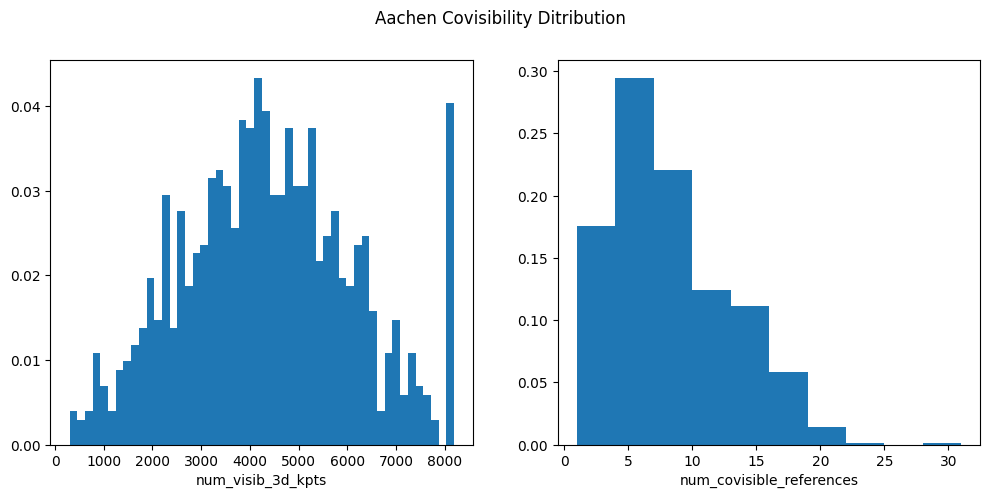

The mean of num_visib_3d_kpts: 4372.063054187192
The median of num_visib_3d_kpts: 4278.0
The mean of num_covisib_imgs: 7.839408866995074
The median of num_covisib_imgs: 7.0


In [46]:
# compute aachen num_visible 3d distribution, num_ref_image ditribution
with open(aachen_covisib_path, "rb") as f:
    aachen_results = pickle.load(f)
imgs = [img for img in aachen_results.keys()]
aachen_num_visib_3d = [len(aachen_results[img]["unique_points"]) for img in imgs]
aachen_num_refs = [len(aachen_results[img]["unique_images"]) for img in imgs]
visualize_covisib_distribution(aachen_num_visib_3d, aachen_num_refs, "Aachen Covisibility Ditribution")

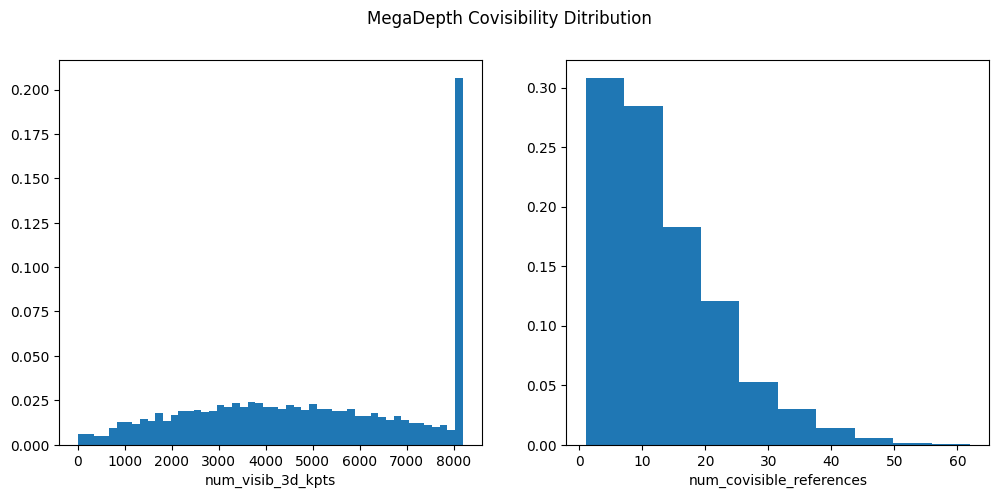

The mean of num_visib_3d_kpts: 4987.679567753312
The median of num_visib_3d_kpts: 4936.0
The mean of num_covisib_imgs: 13.572184292625582
The median of num_covisib_imgs: 11.0


In [47]:
# compute megadepth num_visible 3d distribution, num_ref_image ditribution
mega_num_visib_3d, mega_num_refs = [], []
for scene in scene_names:
    cur_megadepth_covisib_path = megadepth_covisib_path_all_scenes / scene / "covisibility_results.pkl"
    with open(cur_megadepth_covisib_path, "rb") as f:
        scene_results = pickle.load(f)
    scene_imgs = [img for img in scene_results.keys()]
    for img in scene_imgs:
        mega_num_visib_3d.append(len(scene_results[img]["unique_points"]))
        mega_num_refs.append(len(scene_results[img]["unique_images"]))
visualize_covisib_distribution(mega_num_visib_3d, mega_num_refs, "MegaDepth Covisibility Ditribution")

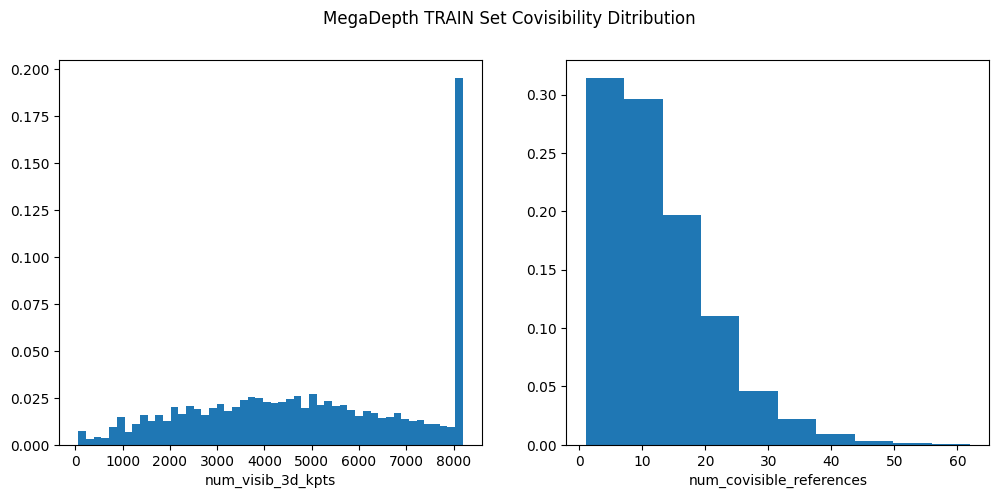

The mean of num_visib_3d_kpts: 5013.862123865627
The median of num_visib_3d_kpts: 4956.0
The mean of num_covisib_imgs: 12.96043623626811
The median of num_covisib_imgs: 11.0


In [4]:
# compute megadepth TRAIN SET num_visible 3d distribution, num_ref_image ditribution
mega_num_visib_3d, mega_num_refs = [], []
for scene in train_scene_names:
    cur_megadepth_covisib_path = megadepth_covisib_path_all_scenes / scene / "covisibility_results.pkl"
    with open(cur_megadepth_covisib_path, "rb") as f:
        scene_results = pickle.load(f)
    scene_imgs = [img for img in scene_results.keys()]
    for img in scene_imgs:
        mega_num_visib_3d.append(len(scene_results[img]["unique_points"]))
        mega_num_refs.append(len(scene_results[img]["unique_images"]))
visualize_covisib_distribution(mega_num_visib_3d, mega_num_refs, "MegaDepth TRAIN Set Covisibility Ditribution")

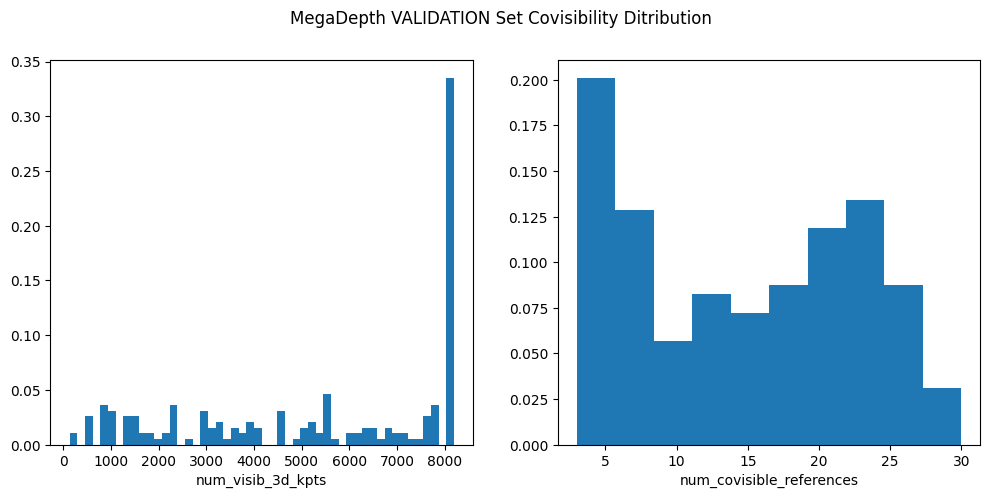

The mean of num_visib_3d_kpts: 5381.6752577319585
The median of num_visib_3d_kpts: 5816.0
The mean of num_covisib_imgs: 14.70103092783505
The median of num_covisib_imgs: 15.0


In [5]:
# compute megadepth VAL SET num_visible 3d distribution, num_ref_image ditribution
mega_num_visib_3d, mega_num_refs = [], []
for scene in val_scene_names:
    cur_megadepth_covisib_path = megadepth_covisib_path_all_scenes / scene / "covisibility_results.pkl"
    with open(cur_megadepth_covisib_path, "rb") as f:
        scene_results = pickle.load(f)
    scene_imgs = [img for img in scene_results.keys()]
    for img in scene_imgs:
        mega_num_visib_3d.append(len(scene_results[img]["unique_points"]))
        mega_num_refs.append(len(scene_results[img]["unique_images"]))
visualize_covisib_distribution(mega_num_visib_3d, mega_num_refs, "MegaDepth VALIDATION Set Covisibility Ditribution")

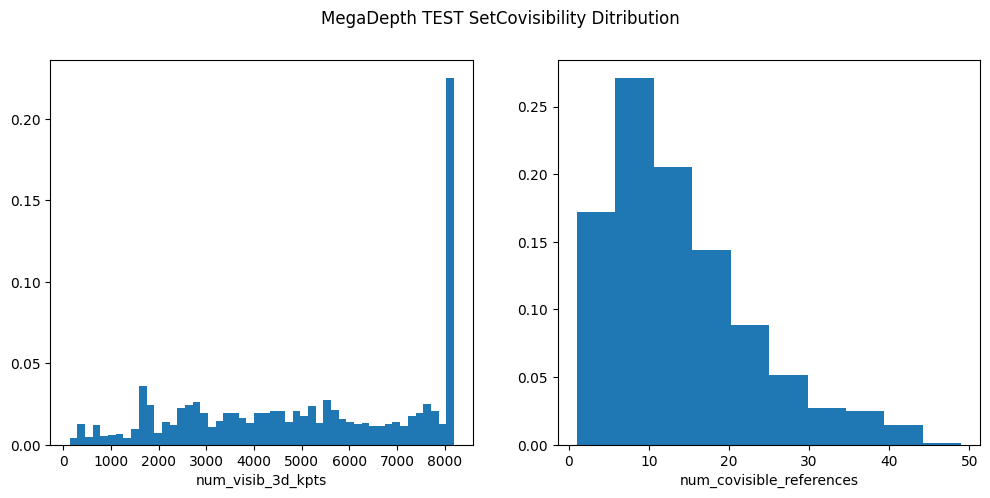

The mean of num_visib_3d_kpts: 5207.734547196934
The median of num_visib_3d_kpts: 5283.0
The mean of num_covisib_imgs: 13.859607091518926
The median of num_covisib_imgs: 12.0


In [6]:
# compute megadepth TEST SET num_visible 3d distribution, num_ref_image ditribution
mega_num_visib_3d, mega_num_refs = [], []
for scene in test_scene_names:
    cur_megadepth_covisib_path = megadepth_covisib_path_all_scenes / scene / "covisibility_results.pkl"
    with open(cur_megadepth_covisib_path, "rb") as f:
        scene_results = pickle.load(f)
    scene_imgs = [img for img in scene_results.keys()]
    for img in scene_imgs:
        mega_num_visib_3d.append(len(scene_results[img]["unique_points"]))
        mega_num_refs.append(len(scene_results[img]["unique_images"]))
visualize_covisib_distribution(mega_num_visib_3d, mega_num_refs, "MegaDepth TEST SetCovisibility Ditribution")

## For visualizing statistic distributions of the averaged 3D descriptors

In [5]:
from pathlib import Path
import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis

In [2]:
aachen_cache_feats_path = Path("/proj/vlarsson/outputs_aachen/covisibility/points3D_feats_cache.h5")
megadepth_cache_feats_all_scenes = Path("/proj/vlarsson/outputs/midterm_results/")
full_mega_scenes_lst = Path(f"/proj/vlarsson/outputs/splits/full_scenes.txt")
train_mega_scenes_lst = Path(f"/proj/vlarsson/outputs/splits/train.txt")
val_mega_scenes_lst = Path(f"/proj/vlarsson/outputs/splits/val.txt")
test_mega_scenes_lst = Path(f"/proj/vlarsson/outputs/splits/test.txt")
scene_names = [line.strip() for line in open(full_mega_scenes_lst, "r").readlines()]
train_scene_names = [line.strip() for line in open(train_mega_scenes_lst, "r").readlines()]
val_scene_names = [line.strip() for line in open(val_mega_scenes_lst, "r").readlines()]
test_scene_names = [line.strip() for line in open(test_mega_scenes_lst, "r").readlines()]

In [6]:
def analyze_distribution(data, label="Dataset"):
    print(f"--- {label} Statistics ---")
    print(f"Mean: {np.mean(data):.4f}")
    print(f"Std: {np.std(data):.4f}")
    print(f"Skewness: {skew(data.flatten()):.4f}")
    print(f"Kurtosis: {kurtosis(data.flatten()):.4f}")
    
    # 1. 元素分布直方图
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.hist(data.flatten(), bins=100, alpha=0.7)
    plt.title(f"{label} Element Distribution")

    # 2. L2 范数分布
    norms = np.linalg.norm(data, axis=1)
    plt.subplot(1, 3, 2)
    plt.hist(norms, bins=50, color='orange')
    plt.title(f"{label} L2-Norms")

    # 3. 维度活跃度 (各维度的方差)
    dim_vars = np.var(data, axis=0)
    plt.subplot(1, 3, 3)
    plt.plot(dim_vars)
    plt.title(f"{label} Variance per Dimension")
    
    plt.tight_layout()
    plt.show()

In [18]:
def load_feats_fast(file_path, feat_dim=256, sample=None):
    with h5py.File(file_path, "r") as f_h5:
        keys = list(f_h5.keys())
        num_items = len(keys)
        if sample is not None:
            keys = np.random.choice(keys, size=sample, replace=False)
            num_items = sample
        all_feats = np.empty((num_items, feat_dim), dtype=np.float32)
        
        for i, key in enumerate(keys):
            all_feats[i] = f_h5[key]["descriptors"][:]
            if i % 1000 == 0:
                print(f"Loading: {i}/{num_items}", end='\r')
                
        return all_feats

--- Aachen Sampled Statistics ---
Mean: -0.0006
Std: 0.0625
Skewness: 0.0071
Kurtosis: -0.0236


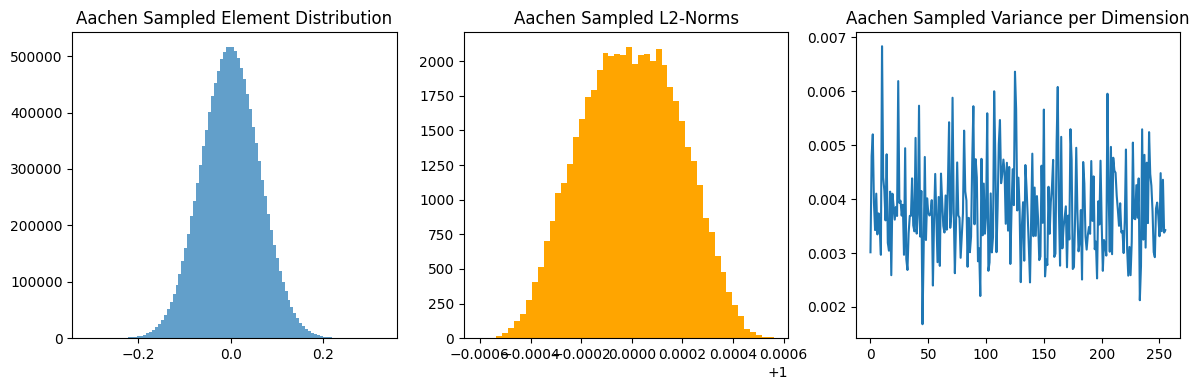

In [17]:
# compute aachen num_visible 3d distribution, num_ref_image distribution
avg_feats = load_feats_fast(aachen_cache_feats_path)
sample_idx = np.random.choice(len(avg_feats), min(50000, len(avg_feats)), replace=False)
analyze_distribution(avg_feats[sample_idx], label="Aachen Sampled")

  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:05<09:28,  5.75s/it]

  2%|▏         | 2/100 [00:06<04:40,  2.86s/it]

  3%|▎         | 3/100 [00:10<05:43,  3.55s/it]

  4%|▍         | 4/100 [00:12<04:09,  2.60s/it]

...

 97%|█████████▋| 97/100 [05:30<00:10,  3.40s/it]

 98%|█████████▊| 98/100 [05:31<00:05,  2.69s/it]

 99%|█████████▉| 99/100 [05:33<00:02,  2.44s/it]

100%|██████████| 100/100 [05:35<00:00,  3.36s/it]


--- Aachen Sampled Statistics ---
Mean: -0.0003
Std: 0.0625
Skewness: 0.0011
Kurtosis: -0.0244


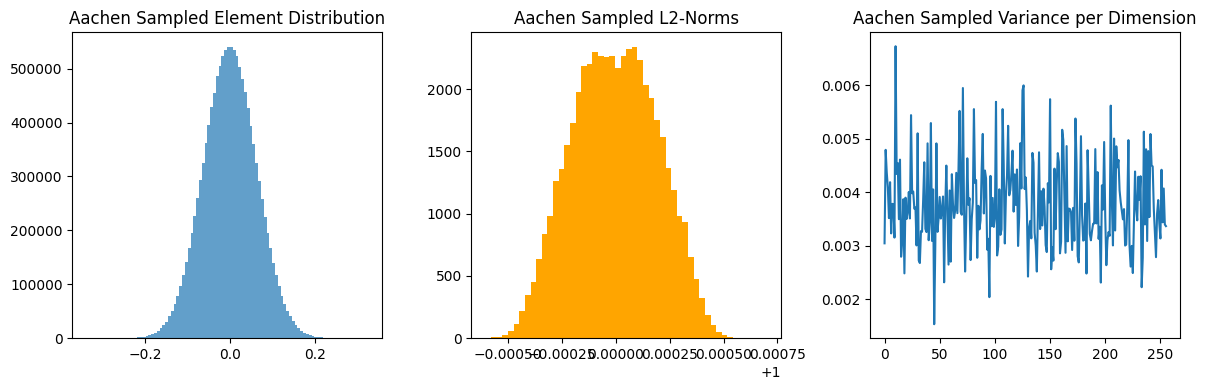

In [ ]:
# compute aachen num_visible 3d distribution, num_ref_image distribution
from tqdm import tqdm
sampled_idx = np.random.choice(len(scene_names), min(100, len(scene_names)), replace=False)
all_scene_feats = []
for id in tqdm(sampled_idx):
    cache_feats_path = megadepth_cache_feats_all_scenes / scene_names[id] / "points3D_feats_cache.h5"
    avg_feats = load_feats_fast(cache_feats_path, sample=1000)
    all_scene_feats.append(avg_feats)
all_feats = np.concatenate(all_scene_feats, axis=0)
sample_idx = np.random.choice(len(all_feats), min(50000, len(all_feats)), replace=False)
analyze_distribution(all_feats[sample_idx], label="MegaDepth Sampled")

In [3]:
from pathlib import Path
root = Path("/proj/vlarsson/datasets/megadepth/Undistorted_SfM")
output_dir = Path("/proj/vlarsson/outputs")
# the scenes exist in MegaDepth
scene_names = sorted([p.name for p in root.iterdir() if p.is_dir()])

In [ ]:
# read gluefactory train_clean list
file_path = "/home/x_jiagu/glue-factory/gluefactory/datasets/megadepth_scene_lists/train_scenes_clean.txt"
with open(file_path,'r')as f:
    gluefactory_lst=[item.strip() for item in f.readlines()]

In [1]:
# read gluefactory val_clean list
with open("/home/x_jiagu/glue-factory/gluefactory/datasets/megadepth_scene_lists/test_scenes_clean.txt",'r') as f:
    test_lst = [item.strip() for item in f.readlines()]

In [ ]:
# read gluefactory test_clean list
with open("/home/x_jiagu/glue-factory/gluefactory/datasets/megadepth_scene_lists/valid_scenes_clean.txt",'r') as f:
    val_lst = [item.strip() for item in f.readlines()]

In [ ]:
# write full list contains all the scenes we are going to use
full_lst = Path(f"/proj/vlarsson/outputs/splits/full_scenes.txt")
with open(full_lst, 'w') as f:
    for s_n in gluefactory_lst:
        f.write(s_n + "\n")
    for s_n in val_lst:
        f.write(s_n + "\n")
    for s_n in test_lst:
        f.write(s_n + "\n")

In [4]:
# create our train, validation and test lists
train_path = Path(f"/proj/vlarsson/outputs/splits/train.txt")
val_path = Path(f"/proj/vlarsson/outputs/splits/val.txt")
test_path = Path(f"/proj/vlarsson/outputs/splits/test.txt")

In [65]:
with open(train_path, "w") as f:
    for scene in gluefactory_lst[:94]:
        f.write(scene + "\n")

In [ ]:
with open(val_path, "w") as f:
    for scene in val_lst:
        f.write(scene + "\n")



In [5]:
with open(test_path, "w") as f:
    for scene in test_lst:
        f.write(scene + "\n")

In [2]:
# read to show the current scenes we are using for train, validation and test
from pathlib import Path

output_dir = Path("/proj/vlarsson/outputs")
scene_lst_path = output_dir / "splits"
current_scene_names = [] 
with open(scene_lst_path / "train.txt", "r") as f:
    for name in f.readlines():
        current_scene_names.append(name.strip())
with open(scene_lst_path / "val.txt", "r") as f:
    for name in f.readlines():
        current_scene_names.append(name.strip())
with open(scene_lst_path / "test.txt", "r") as f:
    for name in f.readlines():
        current_scene_names.append(name.strip())

current_scene_names

['0001',
 '0003',
 '0004',
 '0005',
 '0007',
 '0012',
 '0013',
 '0016',
 '0017',
 '0023',
 '0026',
 '0027',
 '0034',
 '0035',
 '0036',
 '0037',
 '0039',
 '0041',
 '0042',
 '0043',
 '0044',
 '0046',
 '0047',
 '0048',
 '0049',
 '0056',
 '0057',
 '0058',
 '0060',
 '0061',
 '0062',
 '0064',
 '0065',
 '0067',
 '0070',
 '0071',
 '0076',
 '0078',
 '0080',
 '0083',
 '0086',
 '0087',
 '0090',
 '0094',
 '0095',
 '0098',
 '0099',
 '0100',
 '0101',
 '0102',
 '0104',
 '0107',
 '0115',
 '0117',
 '0122',
 '0129',
 '0130',
 '0137',
 '0141',
 '0147',
 '0148',
 '0149',
 '0150',
 '0151',
 '0156',
 '0160',
 '0162',
 '0175',
 '0181',
 '0183',
 '0185',
 '0186',
 '0189',
 '0190',
 '0197',
 '0200',
 '0204',
 '0205',
 '0212',
 '0214',
 '0217',
 '0223',
 '0224',
 '0231',
 '0235',
 '0237',
 '0238',
 '0240',
 '0243',
 '0252',
 '0257',
 '0258',
 '0269',
 '0271',
 '0015',
 '0022',
 '0008',
 '0019',
 '0021',
 '0024',
 '0025',
 '0032',
 '0063']

In [ ]:
# a function that counts queries in a log file, save it in case of further use
import re

def stats_query_counts(file_path):
    total_originally = 0
    total_gt_collected = 0
    scene_count = 0

    pattern_total = re.compile(r"(\d+) queries in total originally")
    pattern_gt = re.compile(r"(\d+) queries that have GT collected")

    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                match_total = pattern_total.search(line)
                if match_total:
                    total_originally += int(match_total.group(1))
                    scene_count += 1
                
                match_gt = pattern_gt.search(line)
                if match_gt:
                    total_gt_collected += int(match_gt.group(1))

        print("="*30)
        print(f"Total Scenes: {scene_count}")
        print(f"Number of Query In Total Originally: {total_originally}")
        print(f"Number of Query With Non-Zero GT: {total_gt_collected}")
        if total_originally > 0:
            print(f"Ratio: {(total_gt_collected / total_originally)*100:.2f}%")
        print("="*30)

    except FileNotFoundError:
        print(f"Error: Couldn't find {file_path}")

In [ ]:
stats_query_counts(Path("/home/x_jiagu/degree_project/log_file/clean_query.log"))

# Below we can visualize covisible reaults, depth info and GT for a specific query. For dubugging why certain queries have low matchable GT ratio. 

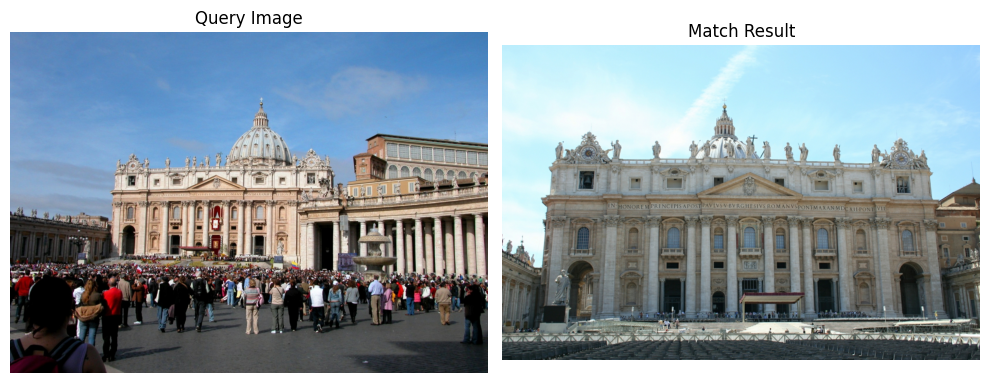

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import pickle

root = Path("/proj/vlarsson/datasets/megadepth/Undistorted_SfM")
scene = "0015"
images_path = root / scene / "images"

test_img_name = '2518736578_578899029c_o.jpg'
ref_img = '170804731_6bf4fbecd4_o.jpg'
img_query = mpimg.imread(images_path / test_img_name)
img_match = mpimg.imread(images_path / ref_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_query)
axes[0].set_title('Query Image')
axes[0].axis('off')

axes[1].imshow(img_match)
axes[1].set_title('Match Result')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [8]:
from generate_gt_pairs_by_scene import generate_gt_for_query_list, load_query_cams
import numpy as np

query_list = ["3722247576_38e151fb3e_o.jpg", "1017541041_394e9f81d4_o.jpg", "2518736578_578899029c_o.jpg"]
output_dir = Path("/proj/vlarsson/outputs")
feats_3d_path = output_dir / "midterm_results" / scene / "points3D_feats_cache.h5" # averaged descriptors for all 3D points
feats_2d_path = output_dir / "sfm" / scene / "feats-superpoint-n2048.h5"
depth_path = Path("/proj/vlarsson/datasets/megadepth/depth_undistorted") / scene # depth maps for all queries
covisibility_result_path = output_dir / "midterm_results" / scene / "covisibility_results.pkl" # covisibility results for all queries
query_pose = output_dir / "query_sets" / scene / "query_image_cameras.txt"

query_cams = load_query_cams(query_pose)
with open(covisibility_result_path, "rb") as f:
            covisibility_dict = pickle.load(f)

In [9]:
import h5py

all_query_feats = {}
query_set = set(query_list)
with h5py.File(feats_2d_path, "r") as f_h5:
    all_keys = set(f_h5.keys())
    for img_name in query_set:
        if img_name in all_keys:
            ds = f_h5[img_name]
            all_query_feats[img_name] = {
                "descriptors": ds["descriptors"][:],
                "scores": ds["scores"][:],
                "keypoints": ds["keypoints"][:]
            }

# load 3d descriptors for all the 3d points
points3d_feats = {}
with h5py.File(feats_3d_path, "r") as f_h5:
    all_keys = set(f_h5.keys())
    for id in list(all_keys):
        ds = f_h5[str(id)]
        points3d_feats[str(id)] = {
            "descriptors": ds["descriptors"][:].reshape(1, 256),
            "keypoints": ds["keypoints"][:].reshape(1, 3),
            "scores": ds["scores"][:]
        }

In [14]:
reproj_thresh=3.0
depth_rel_thresh=0.1
gt_default = generate_gt_for_query_list(
        query_list, feats_2d_path, feats_3d_path, query_cams, 
        covisibility_dict, depth_path, reproj_thresh, depth_rel_thresh
        )
matches = gt_default[test_img_name]["matches0"]
ratio = np.sum( matches != -1) / np.shape(matches)[0]
print(f"reprojection error thresh: {reproj_thresh}; depth thresh:{depth_rel_thresh}")
print(f"Overlap ratio: {ratio}")

reprojection error thresh: 3.0; depth thresh:0.1
Overlap ratio: 0.388671875


In [31]:
reproj_thresh=20.0
depth_rel_thresh=0.5
gt_default = generate_gt_for_query_list(
        query_list, feats_2d_path, feats_3d_path, query_cams, 
        covisibility_dict, depth_path, reproj_thresh, depth_rel_thresh
        )
matches = gt_default[test_img_name]["matches0"]
ratio = np.sum( matches != -1) / np.shape(matches)[0]
print(f"reprojection error thresh: {reproj_thresh}; depth thresh:{depth_rel_thresh}")
print(f"Overlap ratio: {ratio}")

reprojection error thresh: 20.0; depth thresh:0.5
Overlap ratio: 0.00048828125


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from utils import qvec2rotmat
from generate_gt_pairs_by_scene import sample_depth_bilinear

def debug_projection_and_depth(
    kpts2d, pts3d, camera, depth_map, 
    reproj_thresh=3.0, depth_rel_thresh=0.1
):
    R = qvec2rotmat(camera["qvec"])
    t = np.array(camera["tvec"]).reshape(3, 1)
    params = camera["intrinsics"]["params"]
    fx, fy, cx, cy = params[:4]
    
    X_cam = R @ pts3d.T + t  # (3, N3D)
    z_proj = X_cam[2]
    valid_z = z_proj > 0
    behind_cam = np.sum(z_proj <= 0)
    print(f"Points behind camera: {behind_cam} / {len(z_proj)}")

    u = fx * (X_cam[0, valid_z] / z_proj[valid_z]) + cx
    v = fy * (X_cam[1, valid_z] / z_proj[valid_z]) + cy
    
    # Depth Histogram
    if depth_map is not None:
        mask_in_img = (u >= 0) & (u < camera["intrinsics"]["width"]) & \
                      (v >= 0) & (v < camera["intrinsics"]["height"]) & (z_proj > 0)
        
        u_in = u[mask_in_img]
        v_in = v[mask_in_img]
        z_in = z_proj[valid_z][mask_in_img]
        
        depth_real = sample_depth_bilinear(depth_map, u_in, v_in).flatten()

        scale = np.median(depth_real[depth_real>0]) / np.median(z_in)
        print(f"Number of non-zero depth values: {np.shape(depth_real[depth_real>0])[0]}")
        print(f"Non-zero depth:{depth_real[depth_real>0]}")
        print(np.median(depth_real[depth_real>0]))
        print(np.median(z_in))
        print(f"scale: {scale}")
        pts3d_valid = pts3d[np.where(valid_z)[0][mask_in_img]]
        # z_aligned = z_in * scale
        # u_in = u_in * scale
        # v_in = v_in * scale
        # X_cam_aligned = (R @ pts3d_valid.T + t ) * scale
        # z_aligned = X_cam_aligned[2]
        # u_in = fx * (X_cam_aligned[0] / z_aligned) + cx
        # v_in = fy * (X_cam_aligned[1] / z_aligned) + cy

        plt.figure(figsize=(10, 5))
        plt.hist(z_in, bins=50, alpha=0.5, label='Projected Z (from 3D points)')
        plt.hist(depth_real[depth_real>0], bins=50, alpha=0.5, label='GT Depth (from Depth Map)')
        plt.title("Depth Distribution Comparison")
        plt.legend()
        plt.show()

        # Projection error Heatmap
        
        rel_error = np.abs(z_in - depth_real) / (depth_real + 1e-6)
        
        plt.figure(figsize=(8, 6))
        sc = plt.scatter(u_in, v_in, c=rel_error, cmap='jet', s=2, vmin=0, vmax=0.5)
        plt.colorbar(sc, label='Relative Depth Error')
        plt.title(f"Depth Relative Error Map")
        plt.gca().invert_yaxis()
        plt.show()

    from scipy.spatial import cKDTree
    projected = np.stack([u_in.flatten(), v_in.flatten()], axis=1)
    tree = cKDTree(kpts2d)
    dists, _ = tree.query(projected)
    reproj_thresh = 5.0
    mask_good = dists <= reproj_thresh
    mask_bad = ~mask_good

    # Visualize 2d vs 3d projection
    plt.figure(figsize=(8, 6))
    plt.scatter(kpts2d[:, 0], kpts2d[:, 1], s=1, c='gray', label='Detected Keypoints', alpha=0.5)
    plt.scatter(u_in, v_in, s=1, c='red', label='Projected 3D Points', alpha=0.3)
    plt.scatter(
        u_in[mask_good], v_in[mask_good], s=3, c='green', label=f'Projected (Error <= {reproj_thresh})', alpha=0.8
        )
    plt.xlim(0, camera["intrinsics"]["width"])
    plt.ylim(camera["intrinsics"]["height"], 0)
    plt.title("2D Keypoints vs Projected 3D Points")
    plt.legend()
    plt.show()

    print(f"Total Reprojection points: {len(u_in)}")
    print(f"Reprojection error < {reproj_thresh} pixels: {np.sum(mask_good)} ({np.sum(mask_good)/len(u_in)*100:.2f}%)")

Points behind camera: 0 / 6230
Number of non-zero depth values: 249
Non-zero depth:[2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         0.30444336
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 1.4515381  1.3138428  2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         0.97839355 2

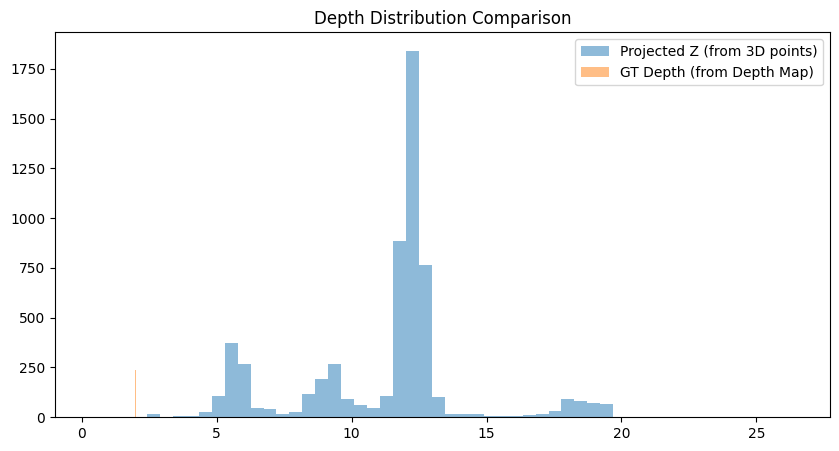

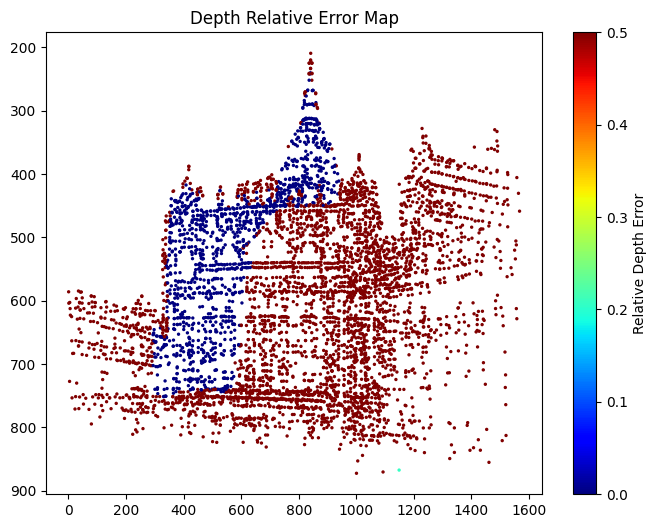

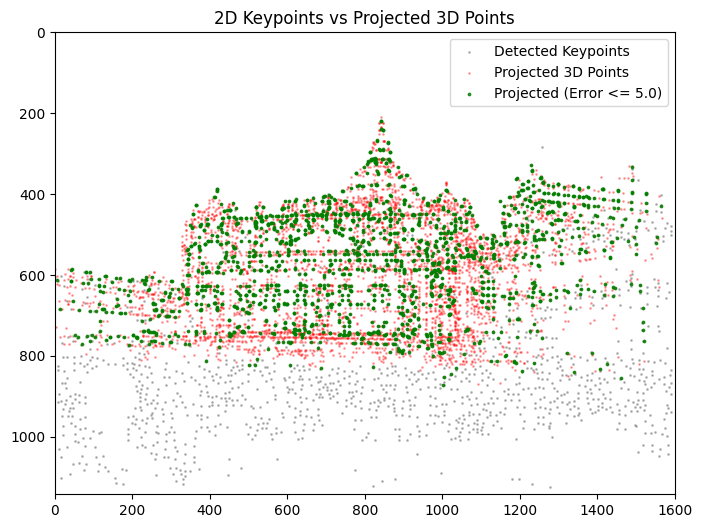

Total Reprojection points: 5848
Reprojection error < 5.0 pixels: 2027 (34.66%)


In [24]:
from generate_gt_pairs_by_scene import load_depth

depth_map = load_depth(depth_path / f"{Path(test_img_name).stem}.h5")
kpts2d = all_query_feats[test_img_name]["keypoints"]

visible_p3d = covisibility_dict[test_img_name]["unique_points"]
valid_p3d = [str(p) for p in visible_p3d if str(p) in points3d_feats]
kpts3d = np.vstack([points3d_feats[p]["keypoints"] for p in valid_p3d])

debug_projection_and_depth(kpts2d, kpts3d, query_cams[test_img_name], depth_map)

## Visualize queries to have an overview

In [2]:
import math
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

In [31]:
import random
from hloc.utils import read_write_model as rw
random.seed(42)
def extract_query_sets_filtered(sfm_model_dir: Path, scene_depth_path: Path, sample_ratio=0.003,query_image_ratio=0.2,
):

    sfm_model_path = sfm_model_dir / "sparse"

    # read the SfM model
    _, images, points3D = rw.read_model(sfm_model_path, ext=".bin")
    point_ids = list(points3D.keys())
    total_points = len(point_ids)
    num_samples = int(total_points * sample_ratio)
    sampled_ids = random.sample(point_ids, num_samples)
    print(f"Original 3D points: {total_points}; Sampled 3D points: {num_samples}")
    def has_depth(image_id):
        img_name = images[image_id].name
        h5_path1 = scene_depth_path / f"{Path(img_name).stem}.h5"
        h5_path2 = scene_depth_path / f"{img_name}.h5"
        return h5_path1.exists() or h5_path2.exists()
    
    # collect image names that observe the sampled 3D points
    oberved_image_ids = set()
    filtered_query_image_ids = set()
    for pid in sampled_ids:
        img_ids_for_point = points3D[pid].image_ids
        oberved_image_ids.update(img_ids_for_point)
        # filter out images without depth maps
        filtered_img_ids = [iid for iid in img_ids_for_point if not has_depth(iid)]
        
        if filtered_img_ids:
            filtered_query_image_ids.update(random.sample(filtered_img_ids,1))

    print(f"Total oberved images: {len(oberved_image_ids)}")
    print(f"Queries filtered as no depth: {len(filtered_query_image_ids)}")
    res = []
    for img_id in filtered_query_image_ids:
        image = images[img_id]
        res.append(image.name)
        
    return res

In [52]:
scene = "0001"
root_path = Path("/proj/vlarsson/datasets/megadepth/Undistorted_SfM") / scene / "images"
query_path = Path("/proj/vlarsson/outputs/query_sets") / scene
query_names_file = query_path / "query_image_names_clean.txt"

In [53]:
# run this cell if you want to visualize the queries that have been filtered out as no depth map
images = extract_query_sets_filtered(
    root_path.parent, root_path.parent.parent.parent / "depth_undistorted"/ scene, sample_ratio=0.003,query_image_ratio=0.2
)
image_paths = [root_path / img_name for img_name in images]
total_images = len(image_paths)
print(f"Found {total_images} images in total.")

Original 3D points: 134678; Sampled 3D points: 404
Total oberved images: 1825
Queries filtered as no depth: 276
Found 276 images in total.


In [50]:
# run this cell if you want to visualize the queries that have been kept (with depth map)
image_paths = []
if not query_names_file.exists():
    raise FileNotFoundError(f"Not found: {query_names_file}")
with open(query_names_file, "r", encoding="utf-8") as f:
    for line in f:
        img_name = line.strip()
        if img_name: 
            full_path = root_path / img_name
            if full_path.exists():
                image_paths.append(full_path)
            else:
                print(f"WARNING: Image not exist -> {full_path}")
total_images = len(image_paths)
print(f"Found {total_images} images in total.")

Found 46 images in total.


Start creating grid image...
Generating grid image...
Image saved to: day_night_check_grid.jpg


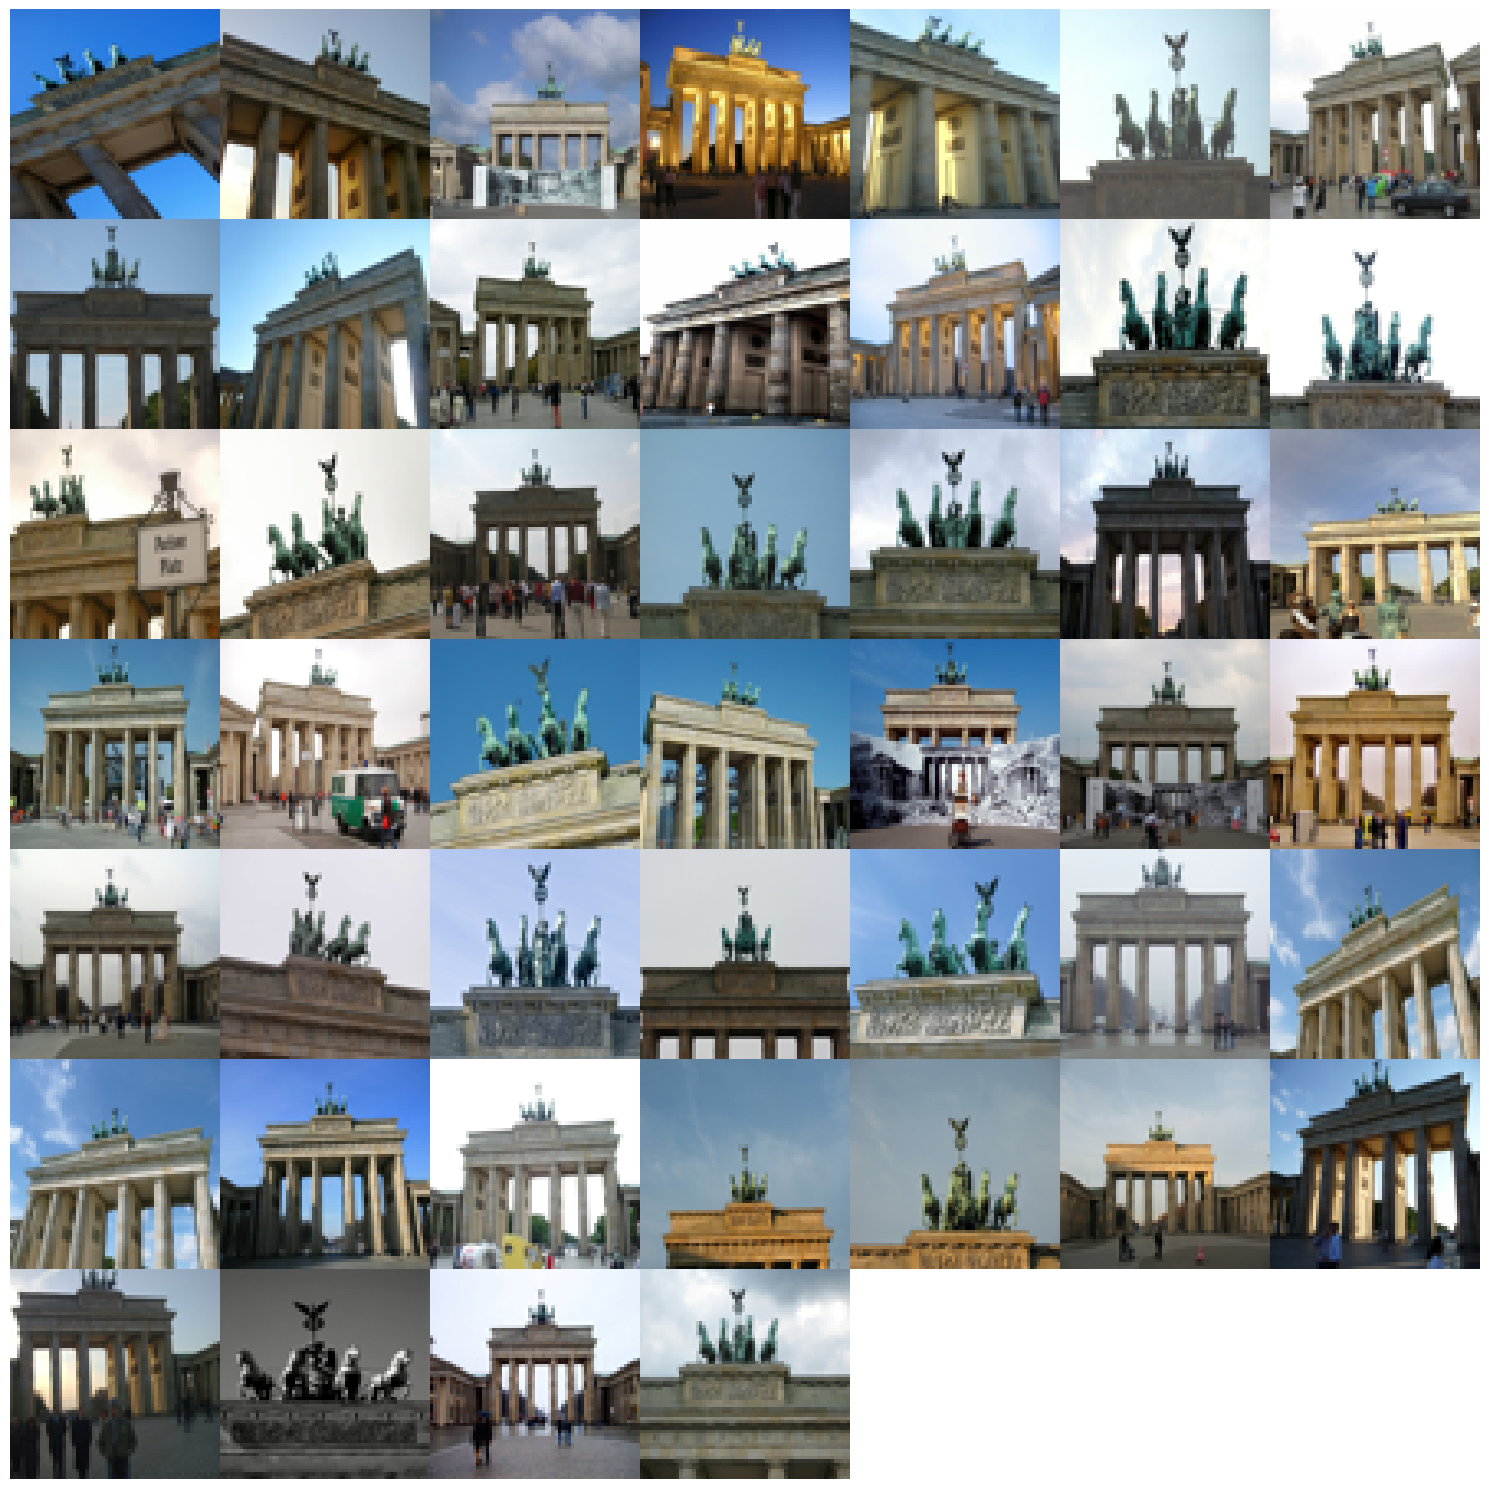

In [51]:
cols = int(math.ceil(math.sqrt(total_images)))
rows = int(math.ceil(total_images / cols))
thumb_size = (64, 64)  

grid_img = Image.new("RGB", (cols * thumb_size[0], rows * thumb_size[1]), color="white")
print("Start creating grid image...")

for idx, img_path in enumerate(image_paths):
    try:
        with Image.open(img_path) as img:
            img_resized = img.convert("RGB").resize(thumb_size)
            r = idx // cols
            c = idx % cols
            x = c * thumb_size[0]
            y = r * thumb_size[1]
            grid_img.paste(img_resized, (x, y))
    except Exception as e:
        print(f"Could not read {img_path}: {e}")

print("Generating grid image...")
plt.figure(figsize=(15, 15))
plt.imshow(grid_img)
plt.axis("off")
plt.tight_layout()

output_save_path = "day_night_check_grid.jpg"
grid_img.save(output_save_path)
print(f"Image saved to: {output_save_path}")

plt.show()